In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
})

Zsun      = 0.02
threshold = 1.00  #threshold for MRR, mB > threshold * mA

cmrr   = "#9467BD"  #purple
cnomrr = "#2CA02C"  #green

In [2]:
# ------------------------------
# Load COMPAS data
# ------------------------------
with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]
    z_vals        = f["z_values"][()]
    Y             = f["yields"][()]
    mass_1        = f["event_properties/mass_1"][()]
    mass_2        = f["event_properties/mass_2"][()]
    zams_1        = f["event_properties/zams_mass_1"][()]
    zams_2        = f["event_properties/zams_mass_2"][()]
    metallicity   = f["event_properties/metallicity"][()]
    MRR_yield     = f["event_properties/MRR"][()]
    formation_weight = f["event_properties/Weight"][()] / 77708655  # starform compas

    # LVK defined M1
    m1_compas = np.maximum(mass_1, mass_2)
    m2_compas = np.minimum(mass_1, mass_2)

    MRR_bh_compas = mass_2 > threshold * mass_1

    Z_compas       = f["event_properties/metallicity"][()]
    logZrel_compas = np.log10(Z_compas / Zsun)

    delay_time_compas = f["event_properties/delay_time_in_years"][()]

    # MASSquerade
    m1_compas_binary_assumption = mass_1
    m2_compas_binary_assumption = mass_2

compas_path = "../sims/fiducial_compas/fiducial/COMPASCompactOutput_BBH_A.h5"

with h5.File(compas_path, "r") as f:
    dco        = f["doubleCompactObjects"]
    m1_raw     = dco["M1"][()].squeeze()
    m2_raw     = dco["M2"][()].squeeze()
    he1_raw    = dco["HeCoreMassDCOFormation1"][()].squeeze()
    he2_raw    = dco["HeCoreMassDCOFormation2"][()].squeeze()

    df_COMPAS = pd.DataFrame({
        "Massrem_0":   dco["M1"][...].squeeze(),
        "Massrem_1":   dco["M2"][...].squeeze(),
        "Mass_0":      dco["M1ZAMS"][...].squeeze(),
        "Mass_1":      dco["M2ZAMS"][...].squeeze(),
        "Metallicity": dco["Metallicity1"][...].squeeze(),
        "MergerTime":  dco["tc"][...].squeeze(),
        "Eccentricity":dco["eccentricityInitial"][...].squeeze(),
        "Semimajor":   dco["separationInitial"][...].squeeze(),
        "Weight":      dco["weight"][...].squeeze(),
    })

AU_TO_RSUN = 215.032
df_COMPAS["Semimajor_Rsun"] = df_COMPAS["Semimajor"] * AU_TO_RSUN

df_COMPAS["PrimaryMass_BH"]   = np.maximum(df_COMPAS["Massrem_0"], df_COMPAS["Massrem_1"])
df_COMPAS["SecondaryMass_BH"] = np.minimum(df_COMPAS["Massrem_0"], df_COMPAS["Massrem_1"])
df_COMPAS["PrimaryZAMS"]   = np.where(df_COMPAS["Massrem_0"] >= df_COMPAS["Massrem_1"], df_COMPAS["Mass_0"], df_COMPAS["Mass_1"])
df_COMPAS["SecondaryZAMS"] = np.where(df_COMPAS["Massrem_0"] <  df_COMPAS["Massrem_1"], df_COMPAS["Mass_0"], df_COMPAS["Mass_1"])
df_COMPAS["Mchirp"] = (
    (df_COMPAS["PrimaryMass_BH"] * df_COMPAS["SecondaryMass_BH"])**(3/5)
    / (df_COMPAS["PrimaryMass_BH"] + df_COMPAS["SecondaryMass_BH"])**(1/5)
)
df_COMPAS["MRR"] = (df_COMPAS["Mass_0"] > df_COMPAS["Mass_1"]) & (df_COMPAS["Massrem_0"] < df_COMPAS["Massrem_1"])

starform_compas = 77708655
df_COMPAS["number_per_solar_mass_values"] = df_COMPAS["Weight"] / starform_compas

In [3]:
# ------------------------------
# Load SEVN data
# ------------------------------
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

# Load SEVN simulation output (raw binary properties)
df_SEVN = pd.read_hdf("../sims/master_bbh.h5", key="bbh")

df_SEVN = df_SEVN.rename(columns={
    "ZAMS_M0":    "zams_mass_1",
    "ZAMS_M1":    "zams_mass_2",
    "Massrem_0":  "mass_1",
    "Massrem_1":  "mass_2",
    "Metallicity":"metallicity",
    "ZAMS_ecc":   "eccentricity",
})

df_SEVN["delay_time_in_years"] = df_SEVN["MergerTime"] * 1e6
df_SEVN["MRR"]   = df_SEVN["mass_2"] > df_SEVN["mass_1"]
df_SEVN["qzams"] = df_SEVN["zams_mass_2"] / df_SEVN["zams_mass_1"]
df_SEVN["logZ"]  = np.log10(df_SEVN["metallicity"] / Zsun)

In [4]:
def analytical_star_forming_mass_per_binary_using_kroupa_imf(
        m1_min, m1_max, m2_min, fbin=1., imf_mass_bounds=[0.01,0.08,0.5,200]
):
    """
    Analytical computation of the mass of stars formed per binary star formed within the
    [m1 min, m1 max] and [m2 min, ..] rage,
    using the Kroupa IMF:

        p(M) \propto M^-0.3 for M between m1 and m2
        p(M) \propto M^-1.3 for M between m2 and m3;
        p(M) = alpha * M^-2.3 for M between m3 and m4;

    @Ilya Mandel's derivation
    """
    m1, m2, m3, m4 = imf_mass_bounds
    if m1_min < m3:
        raise ValueError(f"This analytical derivation requires IMF break m3  < m1_min ({m3} !< {m1_min})")
    alpha = (-(m4**(-1.3)-m3**(-1.3))/1.3 - (m3**(-0.3)-m2**(-0.3))/(m3*0.3) + (m2**0.7-m1**0.7)/(m2*m3*0.7))**(-1) # normalization //Tyler
    # average mass of stars (average mass of all binaries is a factor of 1.5 larger)
    m_avg = alpha * (-(m4**(-0.3)-m3**(-0.3))/0.3 + (m3**0.7-m2**0.7)/(m3*0.7) + (m2**1.7-m1**1.7)/(m2*m3*1.7))
    # fraction of binaries that COMPAS simulates
    fint = -alpha / 1.3 * (m1_max ** (-1.3) - m1_min ** (-1.3)) + alpha * m2_min / 2.3 * (m1_max ** (-2.3) - m1_min ** (-2.3))
    # mass represented by each binary simulated by COMPAS
    m_rep = (1/fint) * m_avg * (1.5 + (1-fbin)/fbin)
    return m_rep

# Below, we caluclate for each binary, so at one Z and one M1 how many binaries did I simulate, this would equate to per event
N_Z = 20 ; N_M1 = 197; N_M2 = 100; N_P = 100; N_e = 20
n_sim_per_binary = N_M1*N_M2*N_P*N_e
print(f"Ntotal systems simulated: {n_sim_per_binary:.2e}")

starform_SEVN = analytical_star_forming_mass_per_binary_using_kroupa_imf(3, 200, 0, 1)
print(starform_SEVN)

# IMF weight
alpha = -2.3
m_min, m_max = 3, 200
norm = (m_max**(alpha + 1) - m_min**(alpha + 1)) / (alpha + 1)
df_SEVN["Weight_norm"] = 197 * (df_SEVN["zams_mass_1"] ** alpha) / norm  # adaptive sampling, need 197

df_SEVN["number_per_solar_mass_values"] = df_SEVN["Weight_norm"] / (starform_SEVN * n_sim_per_binary)

Ntotal systems simulated: 3.94e+07
39.94249161845381


In [5]:
z_idx = 2
df_COMPAS["yield_w"] = Y_compas[z_idx]
df_SEVN["yield_w"]   = Y_sevn[z_idx]

# ── COMPAS channel setup for dR/da plot ──────────────────────────────────────
MRR_mask  = mass_2 > mass_1
cg_mask_c = (he2_raw > he1_raw) & MRR_mask
pp_mask_c = (he2_raw <= he1_raw) & MRR_mask

# semimajor axis — already in df_COMPAS
sep_all_c = df_COMPAS["Semimajor_Rsun"].to_numpy()

# channel splits
sep_cg_c   = sep_all_c[cg_mask_c]
sep_pp_c   = sep_all_c[pp_mask_c]
yield_cg_c = Y_compas[z_idx][cg_mask_c]
yield_pp_c = Y_compas[z_idx][pp_mask_c]

# formation weight channel splits for COMPAS
form_cg_c = formation_weight[cg_mask_c]
form_pp_c = formation_weight[pp_mask_c]

In [6]:
# ── SEVN channel classification ─────

PPISN_TYPE = 3
PISN_TYPE  = 4

def classify_sevn(row):
    if not np.isfinite(row["MHe0_preSN"]) or not np.isfinite(row["MHe1_preSN"]):
        return "nan_MHe"
    if row["MHe1_preSN"] > row["MHe0_preSN"]:
        return "core_growth"
    if row["sn_type_0"] in (PPISN_TYPE, PISN_TYPE) or row["sn_type_1"] in (PPISN_TYPE, PISN_TYPE):
        return "ppisn_shrink"
    return "other"

df_SEVN["channel"] = df_SEVN.apply(classify_sevn, axis=1)
df_mrr_sevn = df_SEVN[df_SEVN["MRR"]].copy()

df_ppisn = df_mrr_sevn[df_mrr_sevn["channel"] == "ppisn_shrink"]
df_core  = df_mrr_sevn[df_mrr_sevn["channel"] == "core_growth"]
df_other = df_mrr_sevn[df_mrr_sevn["channel"] == "other"]

In [7]:
all_sma = np.concatenate([
    df_SEVN["ZAMS_sep"].values,
    df_COMPAS["Semimajor_Rsun"].values
])

bins = np.logspace(
    np.log10(all_sma.min()),
    np.log10(all_sma.max()),
    50
)

def plot_hist_line(ax, data, bins, weights, norm, color, label, ls='-'):
    counts, edges = np.histogram(data, bins=bins, weights=weights)
    centers    = np.sqrt(edges[:-1] * edges[1:])
    log_widths = np.diff(np.log10(edges))
    dNdloga    = counts / log_widths
    dNdloga   /= norm  # shared normalization
    ax.plot(centers, dNdloga, color=color, lw=3, ls=ls, label=label)

# formation weighted

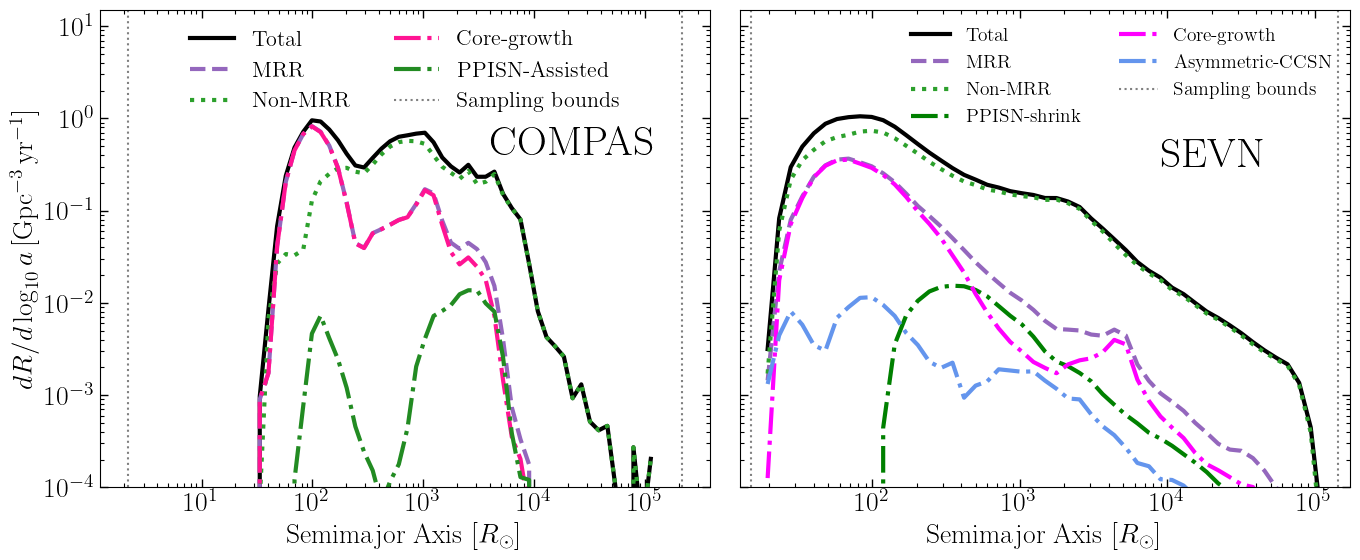

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
compas_bounds = np.array([0.01, 1000]) * AU_TO_RSUN
sevn_bounds   = np.array([0.07,  670]) * AU_TO_RSUN

norm_compas = np.sum(df_COMPAS["number_per_solar_mass_values"])
norm_sevn   = np.sum(df_SEVN["number_per_solar_mass_values"])

# ── LEFT: COMPAS ──────────────────────────────────────────────────────────────
ax = axs[0]
plot_hist_line(ax, df_COMPAS["Semimajor_Rsun"],               bins, df_COMPAS["number_per_solar_mass_values"],              norm_compas, "k",           "Total")
plot_hist_line(ax, df_COMPAS[df_COMPAS["MRR"]]["Semimajor_Rsun"],  bins, df_COMPAS[df_COMPAS["MRR"]]["number_per_solar_mass_values"],  norm_compas, cmrr,          "MRR",           "--")
plot_hist_line(ax, df_COMPAS[~df_COMPAS["MRR"]]["Semimajor_Rsun"], bins, df_COMPAS[~df_COMPAS["MRR"]]["number_per_solar_mass_values"], norm_compas, cnomrr,         "Non-MRR",       ":")
plot_hist_line(ax, sep_cg_c, bins, form_cg_c, norm_compas, "deeppink",    "Core-growth",    "-.")
plot_hist_line(ax, sep_pp_c, bins, form_pp_c, norm_compas, "forestgreen", "PPISN-Assisted", "-.")
ax.set_xlabel(r"Semimajor Axis $[R_\odot]$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(compas_bounds[0], c="gray", ls=":")
ax.axvline(compas_bounds[1], c="gray", ls=":", label="Sampling bounds")

# ── RIGHT: SEVN ───────────────────────────────────────────────────────────────
ax = axs[1]
plot_hist_line(ax, df_SEVN["ZAMS_sep"],               bins, df_SEVN["number_per_solar_mass_values"],              norm_sevn, "k",             "Total")
plot_hist_line(ax, df_SEVN[df_SEVN["MRR"]]["ZAMS_sep"],  bins, df_SEVN[df_SEVN["MRR"]]["number_per_solar_mass_values"],  norm_sevn, cmrr,            "MRR",            "--")
plot_hist_line(ax, df_SEVN[~df_SEVN["MRR"]]["ZAMS_sep"], bins, df_SEVN[~df_SEVN["MRR"]]["number_per_solar_mass_values"], norm_sevn, cnomrr,          "Non-MRR",        ":")
plot_hist_line(ax, df_ppisn["ZAMS_sep"], bins, df_ppisn["number_per_solar_mass_values"], norm_sevn, "green",         "PPISN-shrink",   "-.")
plot_hist_line(ax, df_core["ZAMS_sep"],  bins, df_core["number_per_solar_mass_values"],  norm_sevn, "magenta",       "Core-growth",    "-.")
plot_hist_line(ax, df_other["ZAMS_sep"], bins, df_other["number_per_solar_mass_values"], norm_sevn, "cornflowerblue","Asymmetric-CCSN","-.")
ax.set_xlabel(r"Semimajor Axis $[R_\odot]$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(sevn_bounds[0], c="gray", ls=":")
ax.axvline(sevn_bounds[1], c="gray", ls=":", label="Sampling bounds")

axs[0].text(4e3, 0.4, "COMPAS", fontsize=30)
axs[1].text(9e3, 0.3, "SEVN",   fontsize=30)
axs[0].set_ylabel(r"$dR/d\log_{10} a \, \rm [Gpc^{-3} \, yr^{-1}]$")
axs[0].legend(frameon=False, fontsize=16, ncol=2)
axs[1].legend(frameon=False, fontsize=14, ncol=2)
plt.ylim(1e-4, 15)
plt.tight_layout()
plt.savefig("../plots/final-orbital-sep-formation-weight.pdf")
plt.show()

# MRD weighting

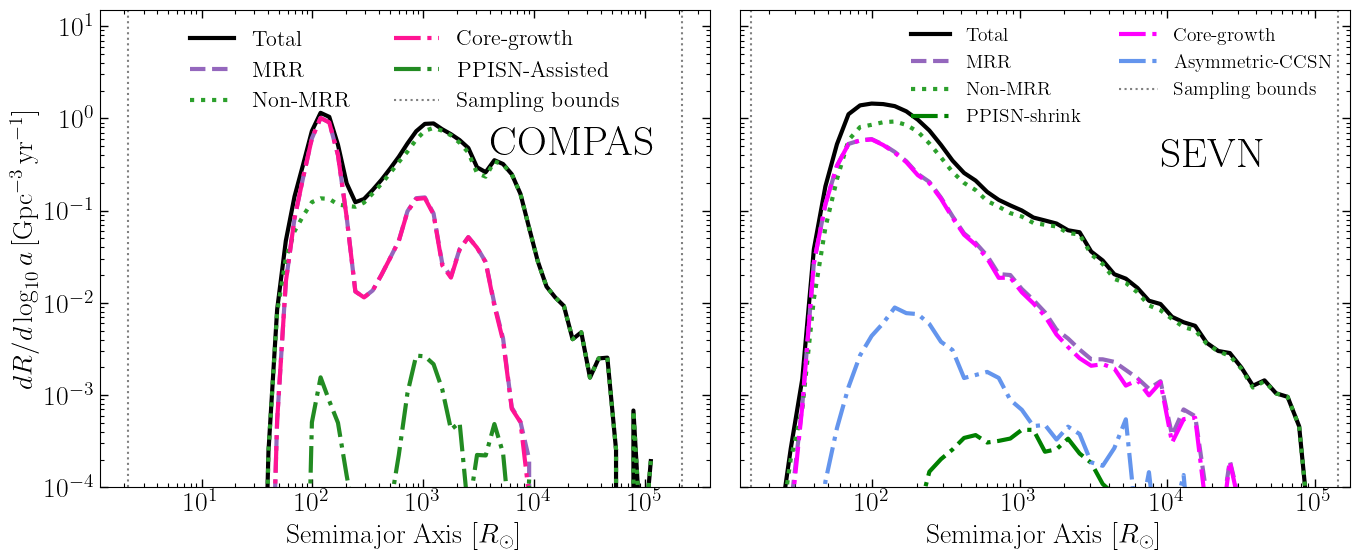

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
compas_bounds = np.array([0.01, 1000]) * AU_TO_RSUN
sevn_bounds   = np.array([0.07,  670]) * AU_TO_RSUN

norm_compas = np.sum(df_COMPAS["yield_w"])
norm_sevn   = np.sum(df_SEVN["yield_w"])

# ── LEFT: COMPAS ──────────────────────────────────────────────────────────────
ax = axs[0]
plot_hist_line(ax, df_COMPAS["Semimajor_Rsun"],               bins, df_COMPAS["yield_w"],              norm_compas, "k",           "Total")
plot_hist_line(ax, df_COMPAS[df_COMPAS["MRR"]]["Semimajor_Rsun"],  bins, df_COMPAS[df_COMPAS["MRR"]]["yield_w"],  norm_compas, cmrr,          "MRR",           "--")
plot_hist_line(ax, df_COMPAS[~df_COMPAS["MRR"]]["Semimajor_Rsun"], bins, df_COMPAS[~df_COMPAS["MRR"]]["yield_w"], norm_compas, cnomrr,         "Non-MRR",       ":")
plot_hist_line(ax, sep_cg_c, bins, yield_cg_c, norm_compas, "deeppink",    "Core-growth",    "-.")
plot_hist_line(ax, sep_pp_c, bins, yield_pp_c, norm_compas, "forestgreen", "PPISN-Assisted", "-.")
ax.set_xlabel(r"Semimajor Axis $[R_\odot]$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(compas_bounds[0], c="gray", ls=":")
ax.axvline(compas_bounds[1], c="gray", ls=":", label="Sampling bounds")

# ── RIGHT: SEVN ───────────────────────────────────────────────────────────────
ax = axs[1]
plot_hist_line(ax, df_SEVN["ZAMS_sep"],               bins, df_SEVN["yield_w"],              norm_sevn, "k",             "Total")
plot_hist_line(ax, df_SEVN[df_SEVN["MRR"]]["ZAMS_sep"],  bins, df_SEVN[df_SEVN["MRR"]]["yield_w"],  norm_sevn, cmrr,            "MRR",            "--")
plot_hist_line(ax, df_SEVN[~df_SEVN["MRR"]]["ZAMS_sep"], bins, df_SEVN[~df_SEVN["MRR"]]["yield_w"], norm_sevn, cnomrr,          "Non-MRR",        ":")
plot_hist_line(ax, df_ppisn["ZAMS_sep"], bins, df_ppisn["yield_w"], norm_sevn, "green",         "PPISN-shrink",   "-.")
plot_hist_line(ax, df_core["ZAMS_sep"],  bins, df_core["yield_w"],  norm_sevn, "magenta",       "Core-growth",    "-.")
plot_hist_line(ax, df_other["ZAMS_sep"], bins, df_other["yield_w"], norm_sevn, "cornflowerblue","Asymmetric-CCSN","-.")
ax.set_xlabel(r"Semimajor Axis $[R_\odot]$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(sevn_bounds[0], c="gray", ls=":")
ax.axvline(sevn_bounds[1], c="gray", ls=":", label="Sampling bounds")

axs[0].text(4e3, 0.4, "COMPAS", fontsize=30)
axs[1].text(9e3, 0.3, "SEVN",   fontsize=30)
axs[0].set_ylabel(r"$dR/d\log_{10} a \, \rm [Gpc^{-3} \, yr^{-1}]$")
axs[0].legend(frameon=False, fontsize=16, ncol=2)
axs[1].legend(frameon=False, fontsize=14, ncol=2)
plt.ylim(1e-4, 15)
plt.tight_layout()
plt.savefig("../plots/final-orbital-sep-yield-weight.pdf")
plt.show()